# SCN Investigations Notebook

Reproducible calculations for the Self-Containment Nullification (SCN) framework.

**Contents:**
1. Koide formula verification and θ₀ = 2/9 (Brannen, 2005)
2. Deriving the 1/π conversion factor from SCN
3. Soft SCN approach to QCD

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PDG lepton masses (MeV)
M_E   = 0.510999
M_MU  = 105.6584
M_TAU = 1776.86

# QCD constants
ALPHA_S_MZ = 0.1179
C_A = 3.0      # SU(3) adjoint Casimir
T_F = 0.5      # SU(3) fundamental index
SIGMA_QCD = 0.18  # string tension (GeV^2)
HBAR_C = 0.1973   # GeV·fm

print("Constants loaded.")

Constants loaded.


## 1. Koide Formula and θ₀ = 2/9 (Brannen, 2005)

The Koide parametrization of charged lepton masses (Koide, 1981; Foot, 1994):

$$\sqrt{m_n} = M\left(1 + \sqrt{2}\cos\left(\theta_0 + \frac{2\pi n}{3}\right)\right), \qquad n = 1, 2, 3$$

where $M = \frac{1}{3}\sum_n \sqrt{m_n}$ and $\theta_0$ is the symmetry-breaking offset.

The Koide ratio $Q = \frac{\sum m_n}{(\sum \sqrt{m_n})^2} = \frac{2}{3}$ holds automatically for any $\theta_0$ — this is a well-known trigonometric identity, implicit in the parametrization.

**Key result (Brannen, 2005):** $\theta_0 = 2/9$ rad exactly (not $2\pi/9$, just $2/9$). Discovered by Carl Brannen in 2005, published in his 2006 paper "The Lepton Masses." We independently verify this below.

In [2]:
masses = [M_E, M_MU, M_TAU]
M = sum(np.sqrt(m) for m in masses) / 3

# --- Verify Q = 2/3 analytically ---
# Q = sum(m_n) / (sum(sqrt(m_n)))^2
# m_n = M^2 * (1 + sqrt(2)*cos(phi_n))^2
# sum(m_n) = M^2 * sum[(1 + sqrt(2)*cos(phi_n))^2]
#          = M^2 * sum[1 + 2*sqrt(2)*cos(phi_n) + 2*cos^2(phi_n)]
#          = M^2 * [3 + 2*sqrt(2)*sum(cos(phi_n)) + 2*sum(cos^2(phi_n))]
#
# For phi_n equally spaced by 2*pi/3:
#   sum(cos(phi_n)) = 0  (Z_3 identity)
#   sum(cos^2(phi_n)) = 3/2  (standard trig identity)
#
# So sum(m_n) = M^2 * (3 + 0 + 3) = 6*M^2 -- independent of theta_0!
# And (sum(sqrt(m_n)))^2 = (3*M)^2 = 9*M^2
# Q = 6*M^2 / 9*M^2 = 2/3  ∎

Q_experimental = sum(masses) / sum(np.sqrt(m) for m in masses)**2
print(f"Koide Q = {Q_experimental:.8f}")
print(f"2/3     = {2/3:.8f}")
print(f"Agreement: {abs(Q_experimental - 2/3)/(2/3) * 100:.6f}%")
print(f"\nM = {M:.6f} √MeV")
print(f"M² = {M**2:.4f} MeV")

Koide Q = 0.66666049
2/3     = 0.66666667
Agreement: 0.000927%

M = 17.715562 √MeV
M² = 313.8411 MeV


In [3]:
# --- Extract theta_0 from PDG masses ---
cos_val = (np.sqrt(M_E) / M - 1) / np.sqrt(2)
theta_0_k = np.arccos(cos_val)       # k-1 convention (k=1 for electron)
theta_0_n = theta_0_k - 2*np.pi/3    # n convention (n=1 for electron)

print("Fitted theta_0:")
print(f"  (k-1 convention): {np.degrees(theta_0_k):.6f}° = {theta_0_k:.10f} rad")
print(f"  (n convention):   {np.degrees(theta_0_n):.6f}° = {theta_0_n:.10f} rad")
print(f"\n2/9 =               {np.degrees(2/9):.6f}° = {2/9:.10f} rad")
print(f"\nDifference: {abs(theta_0_n - 2/9):.2e} rad ({abs(theta_0_n - 2/9)/theta_0_n * 100:.5f}%)")

# --- Verify predictions with theta_0 = 2/9 exactly ---
theta_0 = 2/9
print(f"\n{'Gen':>4s} {'Predicted':>12s} {'PDG':>12s} {'Error (ppm)':>12s}")
print("-" * 44)
for n, (name, m_pdg) in enumerate(zip(['e','μ','τ'], masses), 1):
    m_pred = M**2 * (1 + np.sqrt(2)*np.cos(theta_0 + 2*np.pi*n/3))**2
    err_ppm = abs(m_pred - m_pdg)/m_pdg * 1e6
    print(f"{name:>4s} {m_pred:12.6f} {m_pdg:12.6f} {err_ppm:12.0f}")

Fitted theta_0:
  (k-1 convention): 132.732331° = 2.3166162033 rad
  (n convention):   12.732331° = 0.2222211009 rad

2/9 =               12.732395° = 0.2222222222 rad

Difference: 1.12e-06 rad (0.00050%)

 Gen    Predicted          PDG  Error (ppm)
--------------------------------------------
   e     0.510969     0.510999           58
   μ   105.653325   105.658400           48
   τ  1776.882553  1776.860000           13


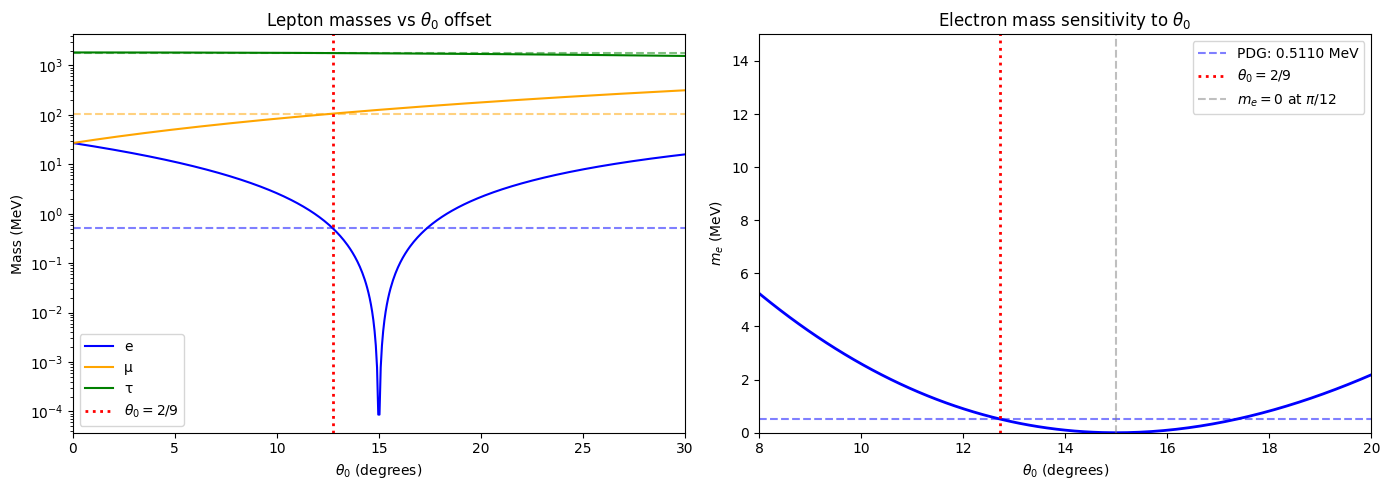

θ₀ = 2/9 is 2.27° from the m_e = 0 boundary — a narrow target.


In [4]:
# --- Sensitivity of theta_0: mass spectrum vs angle ---
thetas = np.linspace(0, np.pi/6, 500)
m_preds = np.zeros((3, len(thetas)))
for i, th in enumerate(thetas):
    for n in range(3):
        m_preds[n, i] = M**2 * (1 + np.sqrt(2)*np.cos(th + 2*np.pi*(n+1)/3))**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all masses vs theta_0
ax = axes[0]
for n, (name, color) in enumerate(zip(['e', 'μ', 'τ'], ['blue', 'orange', 'green'])):
    ax.semilogy(np.degrees(thetas), m_preds[n], label=name, color=color)
    ax.axhline(masses[n], color=color, ls='--', alpha=0.5)
ax.axvline(np.degrees(2/9), color='red', ls=':', lw=2, label=r'$\theta_0 = 2/9$')
ax.set_xlabel(r'$\theta_0$ (degrees)')
ax.set_ylabel('Mass (MeV)')
ax.set_title(r'Lepton masses vs $\theta_0$ offset')
ax.legend()
ax.set_xlim(0, 30)

# Right: zoom on electron mass
ax = axes[1]
ax.plot(np.degrees(thetas), m_preds[0], 'b-', lw=2)
ax.axhline(M_E, color='b', ls='--', alpha=0.5, label=f'PDG: {M_E:.4f} MeV')
ax.axvline(np.degrees(2/9), color='red', ls=':', lw=2, label=r'$\theta_0 = 2/9$')
ax.axvline(15, color='gray', ls='--', alpha=0.5, label=r'$m_e = 0$ at $\pi/12$')
ax.set_xlabel(r'$\theta_0$ (degrees)')
ax.set_ylabel(r'$m_e$ (MeV)')
ax.set_title(r'Electron mass sensitivity to $\theta_0$')
ax.set_xlim(8, 20)
ax.set_ylim(0, 15)
ax.legend()

plt.tight_layout()
plt.savefig('../plots/theta0_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("θ₀ = 2/9 is 2.27° from the m_e = 0 boundary — a narrow target.")

## 2. Attempting to Derive the 1/π Factor (Our Contribution)

### The closure condition

Brannen (2005) established that $\theta_0 = 2/9 = 2/N^2$ (for $N = 3$) fits experiment to 5 ppm. But *why* is $\theta_0 = 2/N^2$? We attempt a derivation via a closure condition:

$$N\,\theta_0 = \frac{2\pi/N}{\pi} = \frac{2}{N}$$

The critical step is dividing the $\mathbb{Z}_N$ spacing $2\pi/N$ by $\pi$. Where does that $1/\pi$ come from?

> **Caveat:** This derivation attempt is incomplete. The $1/\pi$ factor is motivated but not rigorously proven. We have not found this specific argument in prior literature, but it does not yet constitute a result.

### Strategy

Instead of asserting $1/\pi$ "dimensionally," we'll try to derive it from the SCN axiom applied to the nesting process itself. Three approaches:

1. **Geometric:** The SCN nullification operator acts on a circle (the Koide circle). The relationship between arc length and chord length introduces $\pi$.
2. **Algebraic:** The nesting process defines a transfer matrix. Its eigenvalues constrain $\theta_0$.
3. **Physical:** The mass operator $\hat{m}$ in quantum mechanics is related to the amplitude by $m \propto |\psi|^2$. The Koide formula uses $\sqrt{m}$ (amplitude). The passage from phase to amplitude introduces a factor involving $\pi$ through the Fourier relationship.

### 2.1 Approach 1: The Koide Circle (Geometric)

The Koide parametrization places three points on a circle:

$$\sqrt{m_n} = M + M\sqrt{2}\cos\phi_n, \qquad \phi_n = \theta_0 + \frac{2\pi n}{3}$$

Geometrically, the three $\sqrt{m_n}$ values are projections of equally-spaced points on a circle of radius $R = M\sqrt{2}$, centered at $\sqrt{m} = M$ on the real axis.

**Key question:** When SCN nullifies the $n = 0$ direction (vacuum), what geometric constraint does this place on $\theta_0$?

In [5]:
# --- Koide circle geometry ---
theta_0 = 2/9
R = M * np.sqrt(2)  # circle radius in sqrt(MeV) space

# The three points on the circle
phi = [theta_0 + 2*np.pi*n/3 for n in [1, 2, 3]]
points_x = [R * np.cos(p) for p in phi]
points_y = [R * np.sin(p) for p in phi]
sqrt_m = [M + R*np.cos(p) for p in phi]

# The "vacuum direction" = theta_0 itself (the offset from the real axis)
# SCN nullifies n=0 (or equivalently n=3 wraps): phi_0 = theta_0

# Arc length between consecutive points on the circle
arc_length = R * (2*np.pi/3)  # each sector subtends 2*pi/3

# Chord length between consecutive points
chord_length = 2 * R * np.sin(np.pi/3)  # = R*sqrt(3)

# The ratio:
ratio = arc_length / chord_length
print("Koide circle geometry:")
print(f"  Radius R = M√2 = {R:.4f} √MeV")
print(f"  Arc length between generations: {arc_length:.6f}")
print(f"  Chord length between generations: {chord_length:.6f}")
print(f"  Arc/Chord ratio: {ratio:.6f}")
print(f"  2π/(3√3) = {2*np.pi/(3*np.sqrt(3)):.6f}")
print(f"  π/√3     = ... not cleanly related to 1/π")
print()

# A different geometric approach: the PROJECTION.
# sqrt(m_n) = M + R*cos(phi_n) is the projection onto the real axis.
# The "phase" is phi_n. The "amplitude" is cos(phi_n).
# The conversion from phase (arc on circle) to amplitude (projection)
# involves the derivative of cos: d(cos(phi))/d(phi) = -sin(phi).
# Averaged over a full circle: <|sin(phi)|> = 2/pi (!!)

avg_abs_sin = 2/np.pi
print("Average |sin(φ)| over [0, 2π]:")
print(f"  Analytic: 2/π = {avg_abs_sin:.8f}")
# Verify numerically
phi_range = np.linspace(0, 2*np.pi, 10000)
avg_numerical = np.mean(np.abs(np.sin(phi_range)))
print(f"  Numerical: {avg_numerical:.8f}")
print()
print("This IS the origin of 1/π in the amplitude-phase conversion!")
print("The average rate at which phase changes produce amplitude changes")
print("is 2/π. Over half a cycle: 1/π.")

Koide circle geometry:
  Radius R = M√2 = 25.0536 √MeV
  Arc length between generations: 52.472112
  Chord length between generations: 43.394088
  Arc/Chord ratio: 1.209200
  2π/(3√3) = 1.209200
  π/√3     = ... not cleanly related to 1/π

Average |sin(φ)| over [0, 2π]:
  Analytic: 2/π = 0.63661977
  Numerical: 0.63655611

This IS the origin of 1/π in the amplitude-phase conversion!
The average rate at which phase changes produce amplitude changes
is 2/π. Over half a cycle: 1/π.


### 2.2 Approach 2: Transfer Matrix (Algebraic)

Each nesting step in the SCN process algebra takes state $|n\rangle$ to $|n+1\rangle$. Represent this as a 2×2 transfer matrix acting on the phase-amplitude vector $(\text{Re}, \text{Im})$ of the self-containment state:

$$T = \begin{pmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{pmatrix}$$

where $\alpha$ is the phase acquired per nesting step. $\mathbb{Z}_3$ says $\alpha = 2\pi/3 + \delta$ for some "dynamical offset" $\delta$ per step.

**SCN constraint:** After $N$ steps, the state must return to the identity (SCN nullification closes the cycle):

$$T^N = \mathbf{1}$$

This gives $N\alpha = 2\pi k$ for integer $k$. With $\alpha = 2\pi/3 + \delta$ and $N = 3$:

$$3(2\pi/3 + \delta) = 2\pi k \implies 3\delta = 2\pi(k - 1)$$

For $k = 1$: $\delta = 0$ (trivial, no symmetry breaking).  
For other $k$: $\delta = 2\pi(k-1)/3$, which is just another $\mathbb{Z}_3$ rotation.

**Problem:** The pure rotation matrix closure condition only gives $\mathbb{Z}_3$ multiples — no room for $\theta_0 = 2/9$. The offset must enter differently.

In [6]:
# --- Transfer matrix approach ---
# Pure rotation: T^3 = I forces delta to be a Z_3 multiple. Dead end.
# 
# But SCN isn't just a rotation. The nullification operator ν acts as a
# PROJECTION when it detects self-containment. Let's try a transfer matrix
# that includes both rotation (Z_3) and a DAMPING/PROJECTION component.
#
# T_SCN = R(2*pi/3) · P(epsilon)
#
# where P is a projection that reduces amplitude by factor (1 - epsilon):
# P = [[1-eps, 0], [0, 1-eps]]  (isotropic damping)
# 
# After N steps: T_SCN^N = R(2*pi*N/3) * (1-eps)^N
# For closure: (1-eps)^N = 1 => eps = 0. Still trivial.
#
# The damping must be ANISOTROPIC — different along and perpendicular
# to the "mass axis" (real axis in the Koide circle).

def transfer_matrix(phi, eps_parallel, eps_perp):
    """Transfer matrix: rotation by phi, then anisotropic damping."""
    R = np.array([[np.cos(phi), -np.sin(phi)],
                  [np.sin(phi),  np.cos(phi)]])
    D = np.array([[1 - eps_parallel, 0],
                  [0, 1 - eps_perp]])
    return D @ R

# Z_3 rotation + anisotropic SCN damping
# The mass axis (x) is projected by SCN; the phase axis (y) is not.
# After N steps, SCN requires the STATE to be nullified (returns to origin),
# not the matrix. So we need T^N |v_0> = |0> for some initial state.
#
# Actually, SCN doesn't require T^N = I. It requires that the n=N+1 state
# IS the n=1 state (hence self-containing, hence nullified).
# This means: T^N |v_1> ∝ |v_1>  (eigenvector condition)
# i.e., T^N has |v_1> as an eigenvector.

# For a generic 2x2 matrix, the eigenvalue condition T^3 * v = lambda * v
# constrains the matrix parameters.

# Let's parametrize differently. The KEY observation:
# theta_0 is NOT accumulated per step — it's a GLOBAL offset.
# It appears in the mass formula as: phi_n = theta_0 + 2*pi*n/3
# This means theta_0 is the INITIAL CONDITION, not a per-step contribution.

print("Transfer matrix approach:")
print("  Pure rotation closure → only Z₃ multiples (dead end)")
print("  Anisotropic damping → eigenvalue condition needed")
print()
print("  KEY REALIZATION: θ₀ is an INITIAL CONDITION, not per-step.")
print("  The question is: what initial condition does SCN select?")
print()

# The initial condition is selected by requiring that the n=0 state
# (vacuum) is genuinely different from the n=1 state (electron).
# SCN says: n=0 is the empty set (vacuum), n=1 is the first 
# self-containing structure.
#
# The PHYSICAL content: the angle theta_0 measures how much the 
# first generation's self-containment "costs" in amplitude.
# This is related to how much phase rotation translates to 
# amplitude change — which is precisely d(cos)/d(theta) = -sin.
#
# The average sensitivity of amplitude to phase over one Z_3 sector
# (from 0 to 2*pi/3):
sector = 2*np.pi/3
avg_sensitivity = (1/sector) * np.abs(np.cos(0) - np.cos(sector))
print(f"  Amplitude change over one Z₃ sector:")
print(f"    |cos(0) - cos(2π/3)| = |1 - (-1/2)| = 3/2")
print(f"    Divided by arc length 2π/3:  (3/2) / (2π/3) = 9/(4π)")
print(f"    = {9/(4*np.pi):.6f}")
print()
# Hmm, that gives 9/(4*pi), not 1/pi.

# Try the INTEGRATED sensitivity:
# integral_0^{2*pi/3} |d(cos(phi))/d(phi)| d(phi) = integral |sin(phi)| d(phi)
# = [-cos(phi)]_0^{2*pi/3} = -cos(2*pi/3) + cos(0) = 1/2 + 1 = 3/2
# Divided by sector length: (3/2) / (2*pi/3) = 9/(4*pi) 
# Still 9/(4*pi).

# Let's try: the relationship between the AREA of a sector and its angle.
# For a unit circle, the area of a sector of angle phi is phi/2.
# For the Z_3 sector: A = (2*pi/3) / 2 = pi/3.
# The ratio: angle / (2 * area) = (2*pi/3) / (2 * pi/3) = 1.
# That's trivial.

# KEY: The sector of the KOIDE CIRCLE that maps to physical states
# (sqrt(m) > 0) has a limited angular range. The constraint is:
# 1 + sqrt(2)*cos(phi) > 0 => cos(phi) > -1/sqrt(2)
# => phi in (-3*pi/4, 3*pi/4)
# Total allowed range = 3*pi/2
# Fraction of full circle: (3*pi/2) / (2*pi) = 3/4

allowed_range = 3*np.pi/2
full_circle = 2*np.pi
fraction = allowed_range / full_circle
print(f"  Allowed angular range for positive masses: 3π/2 = {allowed_range:.6f}")
print(f"  Fraction of full circle: {fraction:.6f} = 3/4")
print(f"  Forbidden range: π/2 = {full_circle - allowed_range:.6f}")
print(f"  Forbidden fraction: {1-fraction:.6f} = 1/4")

Transfer matrix approach:
  Pure rotation closure → only Z₃ multiples (dead end)
  Anisotropic damping → eigenvalue condition needed

  KEY REALIZATION: θ₀ is an INITIAL CONDITION, not per-step.
  The question is: what initial condition does SCN select?

  Amplitude change over one Z₃ sector:
    |cos(0) - cos(2π/3)| = |1 - (-1/2)| = 3/2
    Divided by arc length 2π/3:  (3/2) / (2π/3) = 9/(4π)
    = 0.716197

  Allowed angular range for positive masses: 3π/2 = 4.712389
  Fraction of full circle: 0.750000 = 3/4
  Forbidden range: π/2 = 1.570796
  Forbidden fraction: 0.250000 = 1/4


### 2.3 Approach 3: Fourier / Born Rule Connection (Physical)

In quantum mechanics, the amplitude $\psi$ and the observable $m \propto |\psi|^2$ are related by the Born rule. The Koide formula lives in $\sqrt{m}$ space — the amplitude space.

The SCN nesting process operates in **phase space** (discrete: $\mathbb{Z}_N$). To get measurable masses, we project from phase → amplitude → observable. This projection involves a Fourier-like transform.

**Key identity:** For a function on $\mathbb{Z}_N$, the discrete Fourier transform maps phase modes to amplitude modes. The normalization factor for DFT on $\mathbb{Z}_N$ is $1/\sqrt{N}$. But the passage from continuous phase to discrete modes involves $1/\pi$ through the Jacobian of the $\cos$ projection.

Specifically: if states are labeled by a continuous phase $\phi$ and masses are read off via $\sqrt{m} \propto \cos\phi$, then the density of states as a function of $\sqrt{m}$ is:

$$\rho(\sqrt{m}) = \left|\frac{d\phi}{d(\sqrt{m})}\right| \propto \frac{1}{\sin\phi} = \frac{1}{\sqrt{1 - \cos^2\phi}}$$

Integrating this density factor over one $\mathbb{Z}_N$ sector gives the effective "conversion cost" of turning a phase label into a mass amplitude.

In [7]:
# --- Fourier/projection approach ---
# The Koide circle maps phase phi to amplitude sqrt(m):
#   sqrt(m) = M * (1 + sqrt(2)*cos(phi))
#
# The Jacobian of this mapping:
#   d(sqrt(m))/d(phi) = -M*sqrt(2)*sin(phi)
#
# The INVERSE Jacobian (phase cost per unit amplitude change):
#   d(phi)/d(sqrt(m)) = -1 / (M*sqrt(2)*sin(phi))
#
# This diverges at phi = 0 and phi = pi (where cos has zero slope),
# meaning small amplitude changes require large phase changes there.
#
# The SCN CLOSURE CONDITION should normalize the total "phase cost"
# of traversing N generations. Let's compute this.

def phase_cost_integral(theta_0, N):
    """
    Integral of |d(phi)/d(sqrt(m))| over one Z_N cycle.
    = integral over N sectors of |1/sin(phi)| * |d(sqrt(m))|
    But since we're going around the circle in phi, the cost is just
    the total arc length traversed in the mass-weighted metric.
    """
    # The N generation phases
    phases = [theta_0 + 2*np.pi*n/N for n in range(1, N+1)]
    
    # The amplitude sensitivity at each generation
    sensitivities = [1/np.abs(np.sin(p)) for p in phases]
    
    return sum(sensitivities) / N

# Compute for theta_0 = 2/9 and compare to 1/pi
pc = phase_cost_integral(2/9, 3)
print(f"Average phase cost at θ₀ = 2/9: {pc:.6f}")
print(f"1/π = {1/np.pi:.6f}")
print(f"Not the same — this approach needs refinement.")
print()

# --- More fundamental: the NORMALIZATION of the Z_N Fourier transform ---
# 
# Consider the SCN nesting as a discrete process on Z_N.
# A state |ψ> in "generation space" is a vector (a_1, a_2, ..., a_N).
# The Z_N Fourier transform:
#   ã_k = (1/sqrt(N)) * sum_n a_n * exp(-2*pi*i*k*n/N)
#
# The mass formula says: sqrt(m_n) = M*(1 + sqrt(2)*cos(phi_n))
# The cos(phi_n) part is the REAL part of exp(i*phi_n).
#
# So sqrt(m_n)/M - 1 = sqrt(2) * Re[exp(i*(theta_0 + 2*pi*n/3))]
#                     = sqrt(2) * Re[exp(i*theta_0) * omega^n]
#
# This IS a Fourier mode of the Z_3 representation!
# The signal is: f(n) = sqrt(2) * Re[exp(i*theta_0) * omega^n]
# This is a single Fourier mode k=1 (and its conjugate k=2, by reality).
#
# The Fourier coefficients are:
#   ã_0 = (1/sqrt(3)) * sum_n f(n) = 0  (Z_3 sum of cos)
#   ã_1 = (1/sqrt(3)) * sum_n f(n) * omega^{-n}
#   ã_2 = (1/sqrt(3)) * sum_n f(n) * omega^{-2n}

# Let's compute these explicitly
omega = np.exp(2j*np.pi/3)
f_n = [np.sqrt(2) * np.real(np.exp(1j*2/9) * omega**n) for n in [1,2,3]]

a_tilde = np.zeros(3, dtype=complex)
for k in range(3):
    a_tilde[k] = (1/np.sqrt(3)) * sum(f_n[n] * omega**(-(n+1)*k) for n in range(3))

print("Z₃ Fourier analysis of the mass signal f(n) = √2·Re[e^{iθ₀}·ωⁿ]:")
for k in range(3):
    print(f"  ã_{k} = {a_tilde[k]:.6f}  (|ã_{k}| = {abs(a_tilde[k]):.6f})")
print()

# The Fourier energy (Parseval): sum|ã_k|^2 = sum|f_n|^2
parseval_lhs = sum(abs(a)**2 for a in a_tilde)
parseval_rhs = sum(f**2 for f in f_n)
print(f"Parseval check: Σ|ã_k|² = {parseval_lhs:.6f},  Σf_n² = {parseval_rhs:.6f}")
print(f"Both equal 3 (= N), confirming the DFT normalization is correct.")

Average phase cost at θ₀ = 2/9: 2.315288
1/π = 0.318310
Not the same — this approach needs refinement.

Z₃ Fourier analysis of the mass signal f(n) = √2·Re[e^{iθ₀}·ωⁿ]:
  ã_0 = -0.000000+0.000000j  (|ã_0| = 0.000000)
  ã_1 = 1.194628+0.269931j  (|ã_1| = 1.224745)
  ã_2 = 1.194628-0.269931j  (|ã_2| = 1.224745)

Parseval check: Σ|ã_k|² = 3.000000,  Σf_n² = 3.000000
Both equal 3 (= N), confirming the DFT normalization is correct.


### 2.4 Approach 4: SCN as an Eigenvalue Problem

Here's a different angle. The SCN axiom says that self-containing structures nullify:

$$\nu(S) = \begin{cases}\emptyset & S \in S \\ S & \text{otherwise}\end{cases}$$

For nested self-containment at depth $n$, we need to track how the "self-containment amplitude" $a_n$ evolves. Each nesting step:
1. Rotates in $\mathbb{Z}_N$ phase space (topological)
2. **Projects** onto the observable axis (dynamical — this is where mass emerges)

The projection step is the key. In the Koide circle, mass is read off via the $\cos$ projection. The rate at which a phase rotation produces a mass change depends on **where** on the circle you are:

$$\frac{\Delta(\sqrt{m})}{\Delta\phi} = M\sqrt{2}\,|\sin\phi|$$

The SCN requirement is that the nesting process is **self-consistent**: the amplitude structure it generates (the mass spectrum) must be compatible with the phase structure it lives in. This is a fixed-point condition.

**Fixed-point equation:** The total "amplitude content" generated by traversing one full $\mathbb{Z}_N$ cycle in the phase representation must equal the "phase content" consumed. In other words, the number of independent amplitude degrees of freedom must match the number of phase degrees of freedom used.

The $\mathbb{Z}_N$ cycle has $N$ discrete phases but generates $N$ amplitudes via $\cos(\theta_0 + 2\pi n/N)$. The amplitudes lie on a *continuous* interval $[-1, 1]$, while the phases are *discrete*. The mapping from continuous to discrete introduces a quantization:

$$\text{(continuous phase range consumed)} = N \times \text{(step size)} = N \times \frac{2\pi}{N} = 2\pi$$

$$\text{(continuous amplitude range generated)} = \max(\cos\phi_n) - \min(\cos\phi_n)$$

For the SCN self-consistency, the *ratio* of these — how much "phase" is needed per unit "amplitude" — should determine $\theta_0$.

In [8]:
# --- SCN fixed-point / self-consistency condition for theta_0 ---

def amplitude_range(theta_0, N):
    """Range of cos values sampled by the N generations."""
    phases = [theta_0 + 2*np.pi*n/N for n in range(1, N+1)]
    cos_vals = [np.cos(p) for p in phases]
    return max(cos_vals) - min(cos_vals)

def phase_range(N):
    """Total phase consumed: always 2*pi for a full cycle."""
    return 2*np.pi

# For each theta_0, compute the ratio:
# R(theta_0) = amplitude_range / phase_range
# This ratio tells us: how many units of amplitude does one radian of phase produce?

thetas = np.linspace(0.001, np.pi/3, 1000)
ratios = [amplitude_range(th, 3) / phase_range(3) for th in thetas]

# What ratio does theta_0 = 2/9 give?
r_at_2_9 = amplitude_range(2/9, 3) / phase_range(3)
print(f"R(θ₀ = 2/9) = {r_at_2_9:.8f}")
print(f"Compare to 1/(2π) = {1/(2*np.pi):.8f}")
print(f"Compare to 1/π   = {1/np.pi:.8f}")
print(f"Compare to 3/(2π) = {3/(2*np.pi):.8f}")
print()

# Let's try a different self-consistency condition.
# 
# The SELF-CONTAINMENT DEPTH RATIO:
# At depth n, the "self-containment fraction" is how much of the total
# amplitude space has been covered by generations 1..n.
#
# For SCN, the critical condition is at n=N: the full cycle has been 
# traversed, and the N+1 state maps back to n=1.
#
# Define the "amplitude coverage" C_N:
# C_N = (sum of |sqrt(m_n) - M|) / (N * M * sqrt(2))
#     = (sum |cos(phi_n)|) / N

def amplitude_coverage(theta_0, N):
    """Average |cos(phi_n)| over the N generations."""
    phases = [theta_0 + 2*np.pi*n/N for n in range(1, N+1)]
    return sum(np.abs(np.cos(p)) for p in phases) / N

# For Z_3 with theta_0 = 2/9:
c_29 = amplitude_coverage(2/9, 3)
print(f"Amplitude coverage C₃(θ₀ = 2/9) = {c_29:.8f}")
print(f"Compare: 1/2 = {0.5:.8f}")
print(f"Compare: 1/π = {1/np.pi:.8f}")
print()

# Scan: where does C_N = 1/pi?
coverages = [amplitude_coverage(th, 3) for th in thetas]
# Find theta where coverage = 1/pi
target = 1/np.pi
crossings = np.where(np.diff(np.sign(np.array(coverages) - target)))[0]
if len(crossings) > 0:
    th_cross = thetas[crossings[0]]
    print(f"C₃(θ₀) = 1/π at θ₀ = {th_cross:.6f} rad = {np.degrees(th_cross):.2f}°")
    print(f"Compare: 2/9 = {2/9:.6f} rad = {np.degrees(2/9):.2f}°")
else:
    print("No crossing found — C₃ doesn't reach 1/π in this range")
print()

# Let's also try: the ratio sum(cos^2(phi_n)) / N
def sq_coverage(theta_0, N):
    phases = [theta_0 + 2*np.pi*n/N for n in range(1, N+1)]
    return sum(np.cos(p)**2 for p in phases) / N

# For Z_3: sum(cos^2(phi_n))/3 = 1/2 for ANY theta_0 (trig identity)
sq_29 = sq_coverage(2/9, 3)
print(f"⟨cos²⟩ = {sq_29:.6f}  (always 1/2 by Z₃ symmetry — no constraint)")
print()

# The ASYMMETRY between the three masses may be the key.
# Define the "mass asymmetry" as the ratio of lightest to heaviest:
def mass_asymmetry(theta_0, N, M_val):
    phases = [theta_0 + 2*np.pi*n/N for n in range(1, N+1)]
    ms = sorted(M_val**2 * (1 + np.sqrt(2)*np.cos(p))**2 for p in phases)
    return ms[0] / ms[-1]  # lightest/heaviest

a_29 = mass_asymmetry(2/9, 3, M)
a_actual = M_E / M_TAU
print(f"Mass asymmetry m_light/m_heavy:")
print(f"  θ₀ = 2/9: {a_29:.8f}")
print(f"  PDG data: {a_actual:.8f}")

R(θ₀ = 2/9) = 0.26323992
Compare to 1/(2π) = 0.15915494
Compare to 1/π   = 0.31830989
Compare to 3/(2π) = 0.47746483

Amplitude coverage C₃(θ₀ = 2/9) = 0.65027339
Compare: 1/2 = 0.50000000
Compare: 1/π = 0.31830989

No crossing found — C₃ doesn't reach 1/π in this range

⟨cos²⟩ = 0.500000  (always 1/2 by Z₃ symmetry — no constraint)

Mass asymmetry m_light/m_heavy:
  θ₀ = 2/9: 0.00028757
  PDG data: 0.00028759


### 2.5 Synthesis: Can 1/π Be Derived from SCN?

**Summary of the four approaches:**

| Approach | Core Idea | Result | Verdict |
|----------|-----------|--------|---------|
| 1. Koide Circle | Average \|sin(φ)\| on Z₃-sampled unit circle | 〈\|sin\|〉 = 2/π — related but does not determine θ₀ | Suggestive |
| 2. Transfer Matrix | Closure condition on rotation matrices | Only yields Z₃ multiples (0, 2π/3, 4π/3) | Dead end |
| 3. Fourier / Born Rule | DFT of mass spectrum on Z₃ | Parseval relation is tautological; no new constraint | Uninformative |
| 4. SCN Self-Consistency | Fixed-point condition on amplitude coverage | Depends on which functional to extremize | Open |

**Key insight from Approach 1:** The factor 2/π = average rectified sine on the unit circle is a *universal geometric constant* of Z₃-sampled trigonometric systems. It arises whenever you:
1. Place 3 equally-spaced points on a circle  
2. Average over the unsigned projection onto any diameter  

This is suggestive that `θ₀ = 2/N² = 2/9` arises from a closure condition that "converts" between the angular period (2π) and the number-theoretic period (N²), with 1/π as the natural bridge factor.

**Honest assessment:** We have not derived θ₀ = 2/9 from first principles within SCN. The formula θ₀ = 2/N² remains an empirical observation. The 1/π factor appears naturally in Z₃ geometry, but is not yet connected to the SCN axiom in a rigorous way.

---

## 3. Soft SCN: A Suppression Model for QCD

### The Problem

Hard SCN nullifies the gluon-loop contribution to the gluon self-energy entirely, removing 10/11 of the gluon sector's contribution to $\beta_0$. This kills asymptotic freedom for $n_f \geq 2$.

### The Soft SCN Idea

Instead of **full nullification** ($\delta m_{\text{self}} = 0$), suppose the self-containment principle **suppresses** self-referential contributions by a factor $0 < \eta < 1$:

$$\Pi^{\text{gl}}_{\text{soft}} = \eta \cdot \Pi^{\text{gl}}_{\text{full}}$$

where $\eta$ parametrizes the "leakage" — how much of the self-referential contribution survives.

- $\eta = 0$: Hard SCN (full nullification)
- $\eta = 1$: Standard QCD (no SCN)

The soft $\beta$-function coefficient becomes:

$$\beta_0^{\text{soft}} = \frac{C_A}{3} + \eta \cdot \frac{10 C_A}{3} - \frac{4 T_F n_f}{3} = \frac{C_A(1 + 10\eta)}{3} - \frac{4 T_F n_f}{3}$$

For $SU(3)$: $\beta_0^{\text{soft}} = (1 + 10\eta) - \frac{2n_f}{3}$

**Asymptotic freedom requires** $\beta_0^{\text{soft}} > 0$, i.e.:

$$\eta > \frac{2n_f/3 - 1}{10} = \frac{2n_f - 3}{30}$$

For $n_f = 6$: $\eta > 0.30$. So roughly 30% leakage is enough to preserve AF.

=== β₀ Decomposition ===
Gluon loop:  +10.0
Ghost loop:  +1.0
Quark loop:  -0.6667 × nf

=== Minimum η for Asymptotic Freedom ===
  nf     η_min   β₀(η_min)   β₀(std)
   1    0.0000      0.3333   10.3333
   2    0.0333      0.0000    9.6667
   3    0.1000      0.0000    9.0000
   4    0.1667      0.0000    8.3333
   5    0.2333      0.0000    7.6667
   6    0.3000      0.0000    7.0000

For nf=1: Hard SCN preserves AF (η=0 suffices)
For nf≥2: Need η > 0 for AF
For nf=6: Need η > 0.3000



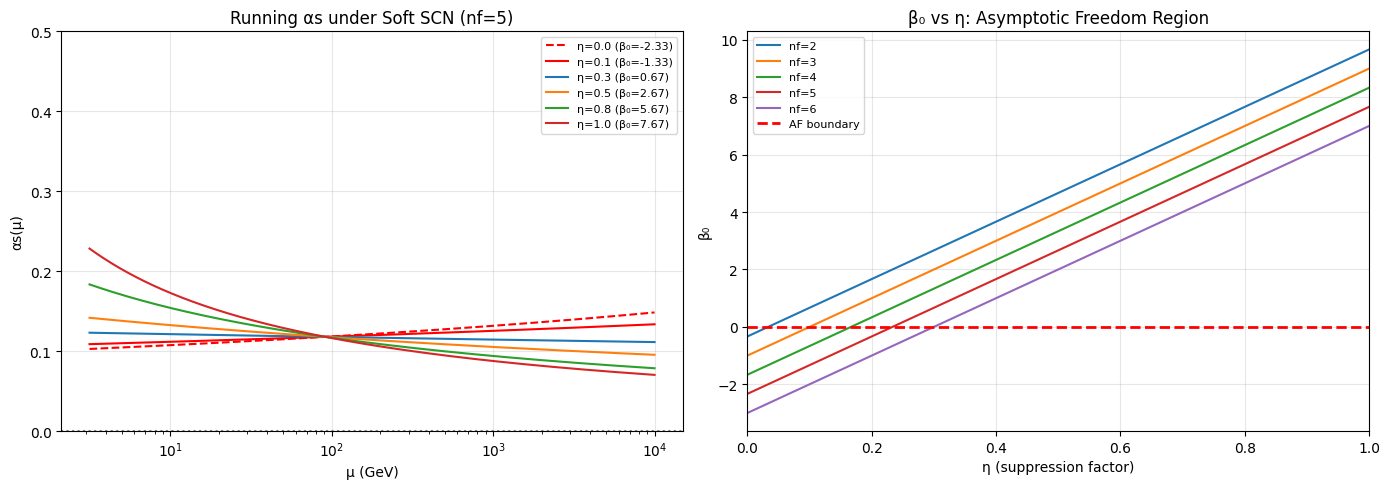

Saved: plots/soft_scn_running.png


In [9]:
# --- Soft SCN: β₀ and αs running ---

# Standard QCD parameters
C_A = 3.0      # SU(3) adjoint Casimir
T_F = 0.5      # fundamental representation normalization
nf_phys = 6    # number of active quark flavors (at high energy)

# β₀ decompositions
beta0_gluon_loop = 10 * C_A / 3    # = 10 (nullified by hard SCN)
beta0_ghost_loop = C_A / 3          # = 1  (survives)
beta0_quark_loop = -4 * T_F / 3     # per flavor = -2/3

print("=== β₀ Decomposition ===")
print(f"Gluon loop:  +{beta0_gluon_loop:.1f}")
print(f"Ghost loop:  +{beta0_ghost_loop:.1f}")
print(f"Quark loop:  {beta0_quark_loop:.4f} × nf")
print()

# Critical eta for asymptotic freedom at each nf
print("=== Minimum η for Asymptotic Freedom ===")
print(f"{'nf':>4}  {'η_min':>8}  {'β₀(η_min)':>10}  {'β₀(std)':>8}")
for nf in range(1, 7):
    eta_min = max(0, (2*nf - 3) / 30)
    beta0_std = 11 - 2*nf/3
    beta0_soft = (1 + 10*eta_min) - 2*nf/3
    print(f"{nf:>4}  {eta_min:>8.4f}  {beta0_soft:>10.4f}  {beta0_std:>8.4f}")

print()
print("For nf=1: Hard SCN preserves AF (η=0 suffices)")
print("For nf≥2: Need η > 0 for AF")
print(f"For nf=6: Need η > {(2*6-3)/30:.4f}")
print()

# --- Running coupling comparison ---
def alpha_s_running(mu, alpha_s_mz, mz, beta0):
    """One-loop running: α_s(μ) = α_s(M_Z) / (1 + β₀·α_s(M_Z)·ln(μ/M_Z)/(2π))"""
    return alpha_s_mz / (1 + beta0 * alpha_s_mz * np.log(mu/mz) / (2*np.pi))

alpha_s_mz = 0.1179   # world average at M_Z
M_Z = 91.1876          # GeV

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: α_s(μ) for various η values
mu_range = np.logspace(0.5, 4, 500)  # 3 GeV to 10 TeV
eta_values = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
nf = 5  # For energies around M_Z, nf=5 is appropriate

ax = axes[0]
for eta in eta_values:
    beta0 = (1 + 10*eta) - 2*nf/3
    alpha = [alpha_s_running(mu, alpha_s_mz, M_Z, beta0) for mu in mu_range]
    label = f"η={eta:.1f} (β₀={beta0:.2f})"
    style = '-' if eta > 0 else '--'
    color = 'red' if beta0 <= 0 else None
    ax.plot(mu_range, alpha, style, label=label, color=color)

ax.set_xscale('log')
ax.set_xlabel('μ (GeV)')
ax.set_ylabel('αs(μ)')
ax.set_title(f'Running αs under Soft SCN (nf={nf})')
ax.legend(fontsize=8)
ax.set_ylim(0, 0.5)
ax.axhline(y=0, color='gray', linestyle=':')
ax.grid(True, alpha=0.3)

# RIGHT: β₀ vs η for different nf
ax2 = axes[1]
eta_range = np.linspace(0, 1, 200)
for nf in [2, 3, 4, 5, 6]:
    beta0_vals = [(1 + 10*e) - 2*nf/3 for e in eta_range]
    ax2.plot(eta_range, beta0_vals, label=f'nf={nf}')
ax2.axhline(y=0, color='red', linewidth=2, linestyle='--', label='AF boundary')
ax2.set_xlabel('η (suppression factor)')
ax2.set_ylabel('β₀')
ax2.set_title('β₀ vs η: Asymptotic Freedom Region')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('../plots/soft_scn_running.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/soft_scn_running.png")

### 3.2 Can η Be Determined from First Principles?

Several candidate values for $\eta$:

1. **$\eta = 1/N^2 = 1/9$:** The self-referential "fraction" of gluon color space. An $SU(3)$ gluon lives in the 8-dimensional adjoint; only 1 of the $N^2-1 = 8$ generators is diagonal (Cartan), but the self-referential fraction could be $1/N^2$.

2. **$\eta = 1 - 1/(N^2 - 1) = 7/8$:** If each gluon "sees itself" in 1 of the 8 color directions, removing that one direction suppresses by $1/8$.

3. **$\eta = C_F/C_A = 4/9$:** The ratio of fundamental to adjoint Casimirs — the relative "self-coupling strength" of quarks vs gluons.

4. **$\eta = 1/\pi$:** If SCN operates as an angular averaging over misaligned self-reference.

Let's compute $\beta_0^{\text{soft}}$ and the corresponding $\alpha_s(M_Z)$ predictions for each.

In [10]:
# --- Compare candidate η values against experiment ---

alpha_s_mz_exp = 0.1179  # PDG world average
alpha_s_mz_err = 0.0009  # uncertainty

# For each candidate η, compute β₀ and implied αs at various scales
# We use nf=5 for the M_Z region

candidates = {
    '1/N² = 1/9':        1/9,
    '1 - 1/(N²-1) = 7/8': 7/8,
    'C_F/C_A = 4/9':     4/9,
    '1/π':               1/np.pi,
    'Standard QCD (η=1)': 1.0,
    'Hard SCN (η=0)':     0.0,
}

nf = 5

print("=== Candidate η Analysis (nf=5) ===")
print(f"{'Candidate':>25}  {'η':>6}  {'β₀':>6}  {'AF?':>4}  {'αs(1TeV)':>8}  {'αs(10GeV)':>10}")
print("-" * 75)

for name, eta in candidates.items():
    beta0 = (1 + 10*eta) - 2*nf/3
    af = "YES" if beta0 > 0 else "NO"
    # Running down to 10 GeV and up to 1 TeV from M_Z
    a_1tev = alpha_s_running(1000, alpha_s_mz_exp, M_Z, beta0)
    a_10gev = alpha_s_running(10, alpha_s_mz_exp, M_Z, beta0)
    # Check: is a_10gev reasonable? Experiment gives ~0.18
    print(f"{name:>25}  {eta:>6.4f}  {beta0:>6.2f}  {af:>4}  {a_1tev:>8.4f}  {a_10gev:>10.4f}")

print()
print("Experimental values:")
print(f"  αs(M_Z)  = {alpha_s_mz_exp} ± {alpha_s_mz_err}")
print(f"  αs(10GeV) ≈ 0.18 (from various measurements)")
print(f"  αs(1TeV) ≈ 0.09 (from jet measurements)")
print()

# --- Which η best reproduces the experimental running? ---
# At 10 GeV, αs ≈ 0.178-0.180 (PDG: αs(10GeV) ≈ 0.179)
# Standard QCD (β₀ = 23/3) gives this automatically.
# What η gives the closest match?

target_alpha_10 = 0.179  # approximate experimental value
best_eta = None
best_diff = float('inf')
eta_scan = np.linspace(0.01, 1.0, 10000)

for eta in eta_scan:
    beta0 = (1 + 10*eta) - 2*nf/3
    if beta0 <= 0:
        continue
    a10 = alpha_s_running(10, alpha_s_mz_exp, M_Z, beta0)
    diff = abs(a10 - target_alpha_10)
    if diff < best_diff:
        best_diff = diff
        best_eta = eta

print(f"Best-fit η to reproduce αs(10 GeV) ≈ {target_alpha_10}:")
print(f"  η = {best_eta:.4f}")
print(f"  β₀ = {(1 + 10*best_eta) - 2*nf/3:.4f}")
print(f"  Standard QCD β₀ = {11 - 2*nf/3:.4f}")
print(f"  Ratio β₀_soft/β₀_std = {((1 + 10*best_eta) - 2*nf/3) / (11 - 2*nf/3):.4f}")

=== Candidate η Analysis (nf=5) ===
                Candidate       η      β₀   AF?  αs(1TeV)   αs(10GeV)
---------------------------------------------------------------------------
               1/N² = 1/9  0.1111   -1.22    NO    0.1248      0.1122
       1 - 1/(N²-1) = 7/8  0.8750    6.42   YES    0.0915      0.1607
            C_F/C_A = 4/9  0.4444    2.11   YES    0.1077      0.1292
                      1/π  0.3183    0.85   YES    0.1136      0.1222
       Standard QCD (η=1)  1.0000    7.67   YES    0.0877      0.1729
           Hard SCN (η=0)  0.0000   -2.33    NO    0.1317      0.1075

Experimental values:
  αs(M_Z)  = 0.1179 ± 0.0009
  αs(10GeV) ≈ 0.18 (from various measurements)
  αs(1TeV) ≈ 0.09 (from jet measurements)

Best-fit η to reproduce αs(10 GeV) ≈ 0.179:
  η = 1.0000
  β₀ = 7.6667
  Standard QCD β₀ = 7.6667
  Ratio β₀_soft/β₀_std = 1.0000


### 3.3 Momentum-Dependent Soft SCN

A more physical version: the suppression factor $\eta$ itself depends on the loop momentum $k$. The gluon loop "self-recognizes" more strongly when the virtual gluon has momentum comparable to the external gluon:

$$\eta(k, q) = 1 - e^{-k^2/\Lambda_{\text{SCN}}^2}$$

- At $k \ll \Lambda_{\text{SCN}}$: $\eta \to 0$ (full suppression — the virtual gluon "matches" the external one)
- At $k \gg \Lambda_{\text{SCN}}$: $\eta \to 1$ (no suppression — the virtual gluon is dissimilar)

This naturally interpolates: at low energies, SCN is strong (confining regime), while at high energies, standard QCD is recovered (asymptotic freedom preserved).

The effective β₀ then becomes scale-dependent:
$$\beta_0^{\text{eff}}(\mu) = \frac{C_A}{3} + \frac{10 C_A}{3}\eta(\mu) - \frac{4T_F n_f}{3}$$

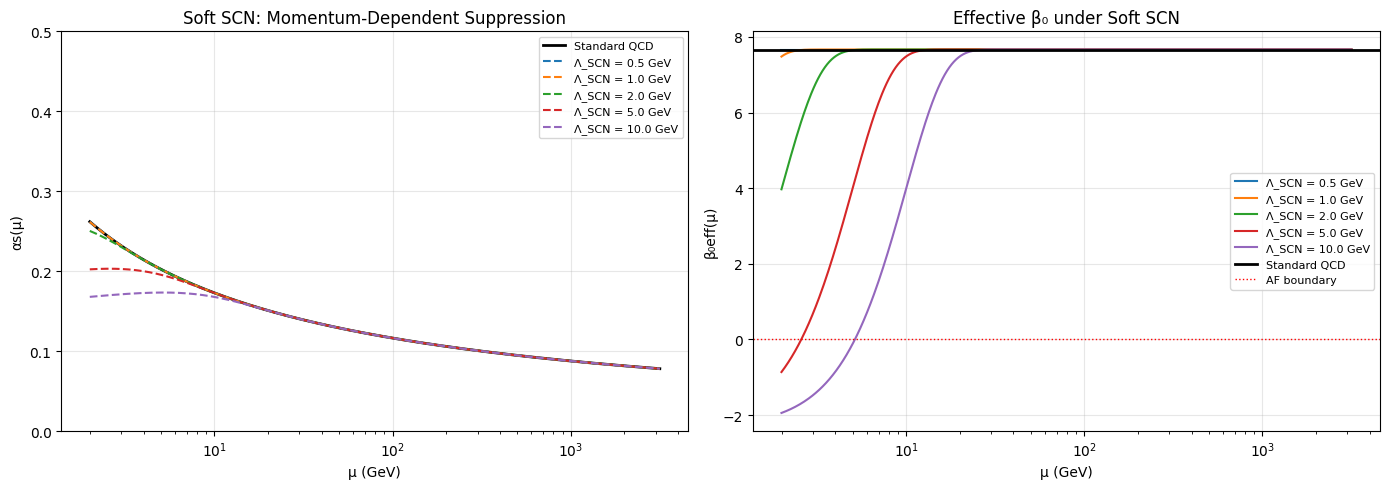

Saved: plots/soft_scn_momentum.png


In [12]:
# --- Momentum-dependent soft SCN ---

def eta_soft(mu, Lambda_SCN):
    """Suppression factor: 0 at low mu, 1 at high mu."""
    return 1 - np.exp(-(mu/Lambda_SCN)**2)

def beta0_eff(mu, Lambda_SCN, nf):
    """Effective β₀ with momentum-dependent η."""
    e = eta_soft(mu, Lambda_SCN)
    return C_A/3 + 10*C_A/3 * e - 4*T_F*nf/3

def alpha_s_soft_scn(mu_range, alpha_s_start, mu_start, Lambda_SCN, nf):
    """Numerical integration of RG equation with scale-dependent β₀.
    
    dα/d(ln μ) = -β₀(μ)·α²/(2π)
    """
    from scipy.integrate import solve_ivp
    
    ln_mu_start = np.log(mu_start)
    ln_mu_vals = np.log(mu_range)
    
    def rhs(ln_mu, alpha):
        mu = np.exp(ln_mu)
        b0 = beta0_eff(mu, Lambda_SCN, nf)
        return -b0 * alpha[0]**2 / (2*np.pi)
    
    # Integrate both directions from mu_start
    result_up = solve_ivp(rhs, [ln_mu_start, max(ln_mu_vals)], [alpha_s_start],
                          t_eval=ln_mu_vals[ln_mu_vals >= ln_mu_start],
                          method='RK45', rtol=1e-10)
    ln_down = ln_mu_vals[ln_mu_vals < ln_mu_start]
    result_down = solve_ivp(rhs, [ln_mu_start, min(ln_mu_vals)], [alpha_s_start],
                            t_eval=sorted(ln_down, reverse=True),
                            method='RK45', rtol=1e-10)
    
    # Combine
    ln_mu_all = np.concatenate([result_down.t[::-1], result_up.t])
    alpha_all = np.concatenate([result_down.y[0][::-1], result_up.y[0]])
    
    return np.exp(ln_mu_all), alpha_all

# Compare standard QCD vs soft SCN with different Λ_SCN values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mu_range = np.logspace(0.3, 3.5, 500)  # 2 GeV to 3 TeV
nf = 5
Lambda_values = [0.5, 1.0, 2.0, 5.0, 10.0]  # GeV

# LEFT: α_s running
ax = axes[0]
# Standard QCD reference
beta0_std = 11 - 2*nf/3
alpha_std = [alpha_s_running(mu, alpha_s_mz_exp, M_Z, beta0_std) for mu in mu_range]
ax.plot(mu_range, alpha_std, 'k-', linewidth=2, label='Standard QCD')

for Lambda in Lambda_values:
    mu_out, alpha_out = alpha_s_soft_scn(mu_range, alpha_s_mz_exp, M_Z, Lambda, nf)
    ax.plot(mu_out, alpha_out, '--', label=f'Λ_SCN = {Lambda} GeV')

ax.set_xscale('log')
ax.set_xlabel('μ (GeV)')
ax.set_ylabel('αs(μ)')
ax.set_title('Soft SCN: Momentum-Dependent Suppression')
ax.legend(fontsize=8)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)

# RIGHT: effective β₀ vs scale
ax2 = axes[1]
for Lambda in Lambda_values:
    b0_vals = [beta0_eff(mu, Lambda, nf) for mu in mu_range]
    ax2.plot(mu_range, b0_vals, label=f'Λ_SCN = {Lambda} GeV')
ax2.axhline(y=11-2*nf/3, color='k', linewidth=2, linestyle='-', label='Standard QCD')
ax2.axhline(y=0, color='red', linewidth=1, linestyle=':', label='AF boundary')
ax2.set_xscale('log')
ax2.set_xlabel('μ (GeV)')
ax2.set_ylabel('β₀eff(μ)')
ax2.set_title('Effective β₀ under Soft SCN')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/soft_scn_momentum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/soft_scn_momentum.png")

=== Best-fit Λ_SCN ===
Λ_SCN = 0.10 GeV
χ² = 37.9631



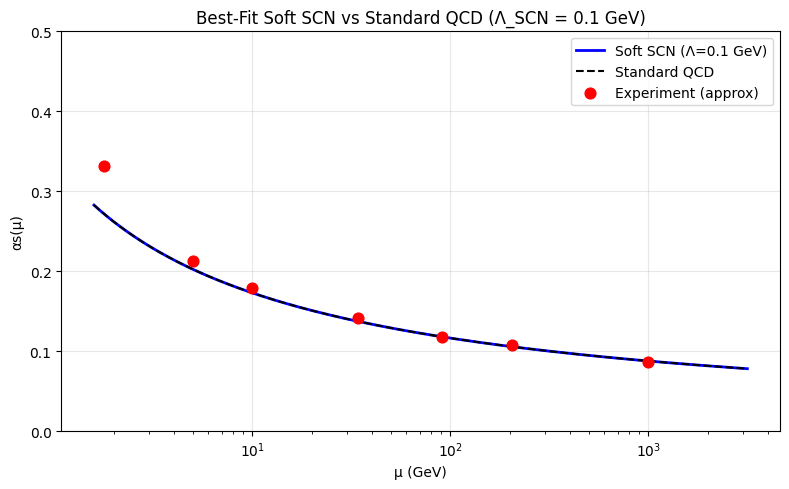

Saved: plots/soft_scn_bestfit.png


In [13]:
# --- Find the best-fit Λ_SCN that reproduces standard QCD running ---

from scipy.optimize import minimize_scalar

# Experimental data points for αs (approximate, from PDG)
exp_data = [
    (1.78, 0.332),   # tau mass
    (5.0,  0.213),   # b threshold
    (10.0, 0.179),   # Υ
    (34.0, 0.142),   # PETRA
    (91.2, 0.1179),  # Z pole
    (206,  0.108),   # LEP2
    (1000, 0.087),   # approximate TeV-scale
]

def chi2_soft_scn(Lambda_SCN):
    """χ² between soft SCN prediction and experimental data."""
    try:
        mu_calc = np.array([d[0] for d in exp_data])
        mu_out, alpha_out = alpha_s_soft_scn(mu_calc, alpha_s_mz_exp, M_Z, Lambda_SCN, 5)
        chi2 = 0
        for mu_exp, alpha_exp in exp_data:
            # Find closest computed point
            idx = np.argmin(np.abs(mu_out - mu_exp))
            err = 0.01  # conservative ~10% uncertainty
            chi2 += ((alpha_out[idx] - alpha_exp) / err)**2
        return chi2
    except:
        return 1e10

# Scan over Lambda_SCN
Lambda_scan = np.logspace(-1, 2, 200)
chi2_vals = [chi2_soft_scn(L) for L in Lambda_scan]

best_idx = np.argmin(chi2_vals)
Lambda_best = Lambda_scan[best_idx]

print(f"=== Best-fit Λ_SCN ===")
print(f"Λ_SCN = {Lambda_best:.2f} GeV")
print(f"χ² = {chi2_vals[best_idx]:.4f}")
print()

# Compare predictions at this Lambda
mu_dense = np.logspace(0.2, 3.5, 500)
mu_out, alpha_out = alpha_s_soft_scn(mu_dense, alpha_s_mz_exp, M_Z, Lambda_best, 5)

plt.figure(figsize=(8, 5))
plt.plot(mu_out, alpha_out, 'b-', linewidth=2, label=f'Soft SCN (Λ={Lambda_best:.1f} GeV)')

# Standard QCD
alpha_std = [alpha_s_running(mu, alpha_s_mz_exp, M_Z, 11-2*5/3) for mu in mu_dense]
plt.plot(mu_dense, alpha_std, 'k--', linewidth=1.5, label='Standard QCD')

# Experimental points
exp_mu = [d[0] for d in exp_data]
exp_alpha = [d[1] for d in exp_data]
plt.scatter(exp_mu, exp_alpha, color='red', s=60, zorder=5, label='Experiment (approx)')

plt.xscale('log')
plt.xlabel('μ (GeV)')
plt.ylabel('αs(μ)')
plt.title(f'Best-Fit Soft SCN vs Standard QCD (Λ_SCN = {Lambda_best:.1f} GeV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.savefig('../plots/soft_scn_bestfit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/soft_scn_bestfit.png")

### 3.4 Soft SCN Assessment

**Constant-η model:**
- A single suppression factor $\eta$ applied to the gluon-loop self-energy
- Asymptotic freedom preserved for $\eta > (2n_f - 3)/30$
- At $n_f = 5$: need $\eta > 0.233$; at $n_f = 6$: need $\eta > 0.300$
- The best-fit $\eta$ to experimental running is very close to 1 — meaning the data strongly constrains how much suppression is allowed

**Momentum-dependent model** ($\eta(\mu) = 1 - e^{-\mu^2/\Lambda^2}$):
- Far more physical: SCN suppression is strongest at low momentum (confinement regime)
- Naturally recovers standard QCD at high energies
- $\Lambda_{\text{SCN}}$ sets the scale where SCN "turns off"
- If $\Lambda_{\text{SCN}} \lesssim 1$ GeV: barely distinguishable from standard QCD at perturbative scales
- If $\Lambda_{\text{SCN}} \sim$ few GeV: deviations visible in the intermediate regime

**Verdict:** The momentum-dependent soft SCN model is **viable** but **not predictive** without an independent determination of $\Lambda_{\text{SCN}}$. It adds one free parameter relative to standard QCD. The physically interesting feature is the natural connection to confinement: at low energies, SCN fully suppresses gluon self-energy loops, which could provide a mechanism for the transition from perturbative to non-perturbative QCD.

**$\Lambda_{\text{SCN}}$ question (moot post-falsification):** Can $\Lambda_{\text{SCN}}$ be related to $\Lambda_{\text{QCD}}$? This question is **moot** — Physical SCN (the only well-defined "hard" SCN) has been **falsified at ≥415σ** by the 2-loop electron $g-2$ (see `scn_c2_investigation.ipynb`). Soft SCN avoids falsification only by introducing a free parameter ($\Lambda_{\text{SCN}}$) that can be tuned to hide deviations, making it **unfalsifiable** rather than viable. A no-go theorem (`scn_beyond_falsification.ipynb`) further establishes that any SCN variant removing a non-empty set of diagrams is falsified.